In [21]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset, random_split
import torchvision.datasets as datasets
import os
%matplotlib inline

In [22]:
import warnings
warnings.filterwarnings("ignore")

In [23]:
plt.rcParams['axes.grid'] = True

In [24]:
roots = [2.2691853142129728, 2.104982167992544, 1.932307699120554, 1.749339162933206, 1.5536238493280832, 1.34187327905057, 1.109960313758399, 0.8541630993606272, 0.5762735442012712, 0.2885386111960936, 0.03198372863548067]
jds = [0.0, -0.1, -0.2, -0.3, -0.4, -0.5, -0.6, -0.7, -0.8, -0.9, -1.0]
get_crit_T = dict(zip(jds, roots))

In [25]:
Jd = 0.0

num_temps = 20
T_c = get_crit_T[Jd]
T = np.linspace(T_c - 0.3, T_c + 0.3, num_temps)

L = 10
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_10 = np.load(f) 
L = 20
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_20 = np.load(f) 
L = 30
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_30 = np.load(f)
L = 40
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_40 = np.load(f)
L = 60
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_60 = np.load(f) 
L = 80
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_80 = np.load(f) 

In [26]:
def errs(errs):
    return np.array([sum(errs[i*512:(i+1)*512])/512 for i in range(num_temps)])

def stds_err(errs):
    return np.array([np.std(errs[i*512:(i+1)*512]) for i in range(num_temps)])

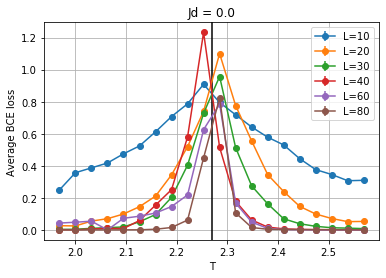

In [27]:
plt.errorbar(T, errs(errs_10), yerr=stds_err(errs_10)/1000, marker='o', label='L=10')
plt.errorbar(T, errs(errs_20), yerr=stds_err(errs_20)/1000, marker='o', label='L=20')
plt.errorbar(T, errs(errs_30), yerr=stds_err(errs_30)/1000, marker='o', label='L=30')
plt.errorbar(T, errs(errs_40), yerr=stds_err(errs_40)/1000, marker='o', label='L=40')
plt.errorbar(T, errs(errs_60), yerr=stds_err(errs_60)/1000, marker='o', label='L=60')
plt.errorbar(T, errs(errs_80), yerr=stds_err(errs_80)/1000, marker='o', label='L=80')

plt.title('Jd = 0.0')
plt.xlabel('T')
plt.ylabel('Average BCE loss')
plt.axvline(x=T_c, color='black')
plt.legend()
#plt.xlim(T_c-0.1, T_c+0.1)
plt.show()

In [28]:
Jd = -0.3

num_temps = 20
T_c = get_crit_T[Jd]
T = np.linspace(T_c - 0.3, T_c + 0.3, num_temps)

L = 10
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_10 = np.load(f) 
L = 20
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_20 = np.load(f) 
L = 30
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_30 = np.load(f)
L = 40
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_40 = np.load(f)
L = 60
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_60 = np.load(f)
L = 80
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_80 = np.load(f)

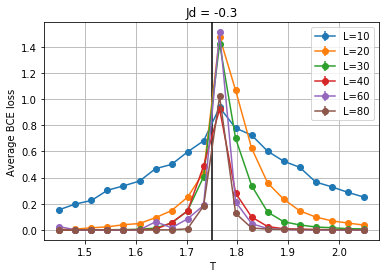

In [29]:
plt.errorbar(T, errs(errs_10), yerr=stds_err(errs_10)/1000, marker='o', label='L=10')
plt.errorbar(T, errs(errs_20), yerr=stds_err(errs_20)/1000, marker='o', label='L=20')
plt.errorbar(T, errs(errs_30), yerr=stds_err(errs_30)/1000, marker='o', label='L=30')
plt.errorbar(T, errs(errs_40), yerr=stds_err(errs_40)/1000, marker='o', label='L=40')
plt.errorbar(T, errs(errs_60), yerr=stds_err(errs_60)/1000, marker='o', label='L=60')
plt.errorbar(T, errs(errs_80), yerr=stds_err(errs_80)/1000, marker='o', label='L=80')

plt.title('Jd = -0.3')
plt.xlabel('T')
plt.ylabel('Average BCE loss')
plt.axvline(x=T_c, color='black')
plt.legend()
#plt.xlim(T_c-0.1, T_c+0.1)
plt.show()

In [30]:
Jd = -0.5

num_temps = 20
T_c = get_crit_T[Jd]
T = np.linspace(T_c - 0.3, T_c + 0.3, num_temps)

L = 10
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_10 = np.load(f) 
L = 20
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_20 = np.load(f) 
L = 30
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_30 = np.load(f)
L = 40
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_40 = np.load(f)
L = 60
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_60 = np.load(f) 
L = 80
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_80 = np.load(f) 

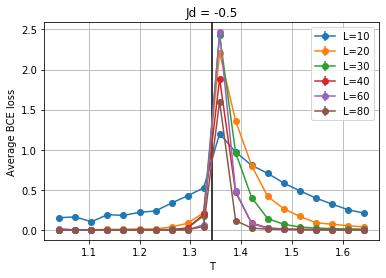

In [31]:
plt.errorbar(T, errs(errs_10), yerr=stds_err(errs_10)/1000, marker='o', label='L=10')
plt.errorbar(T, errs(errs_20), yerr=stds_err(errs_20)/1000, marker='o', label='L=20')
plt.errorbar(T, errs(errs_30), yerr=stds_err(errs_30)/1000, marker='o', label='L=30')
plt.errorbar(T, errs(errs_40), yerr=stds_err(errs_40)/1000, marker='o', label='L=40')
plt.errorbar(T, errs(errs_60), yerr=stds_err(errs_60)/1000, marker='o', label='L=60')
plt.errorbar(T, errs(errs_80), yerr=stds_err(errs_60)/1000, marker='o', label='L=80')

plt.title('Jd = -0.5')
plt.xlabel('T')
plt.ylabel('Average BCE loss')
plt.axvline(x=T_c, color='black')
plt.legend()
#plt.xlim(T_c-0.1, T_c+0.1)
plt.show()

In [32]:
Jd = -0.7

num_temps = 20
T_c = get_crit_T[Jd]
T = np.linspace(T_c - 0.3, T_c + 0.3, num_temps)

L = 10
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_10 = np.load(f) 
L = 20
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_20 = np.load(f) 
L = 30
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_30 = np.load(f)
L = 40
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_40 = np.load(f)
L = 60
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_60 = np.load(f)
L = 80
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_80 = np.load(f)

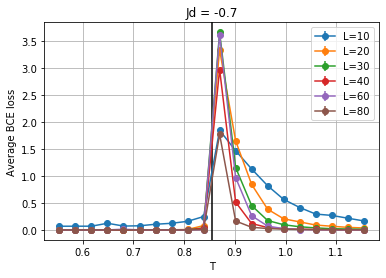

In [33]:
plt.errorbar(T, errs(errs_10), yerr=stds_err(errs_10)/1000, marker='o', label='L=10')
plt.errorbar(T, errs(errs_20), yerr=stds_err(errs_20)/1000, marker='o', label='L=20')
plt.errorbar(T, errs(errs_30), yerr=stds_err(errs_30)/1000, marker='o', label='L=30')
plt.errorbar(T, errs(errs_40), yerr=stds_err(errs_40)/1000, marker='o', label='L=40')
plt.errorbar(T, errs(errs_60), yerr=stds_err(errs_60)/1000, marker='o', label='L=60')
plt.errorbar(T, errs(errs_80), yerr=stds_err(errs_80)/1000, marker='o', label='L=80')

plt.title('Jd = -0.7')
plt.xlabel('T')
plt.ylabel('Average BCE loss')
plt.axvline(x=T_c, color='black')
plt.legend()
#plt.xlim(T_c-0.1, T_c+0.1)
plt.show()

In [34]:
Jd = -0.9

num_temps = 20
T_c = get_crit_T[Jd]
T = np.linspace(T_c - 0.3, T_c + 0.3, num_temps)

L = 10
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_10 = np.load(f) 
L = 20
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_20 = np.load(f) 
L = 30
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_30 = np.load(f)
L = 40
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_40 = np.load(f)
L = 60
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_60 = np.load(f)
L = 80
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_80 = np.load(f)

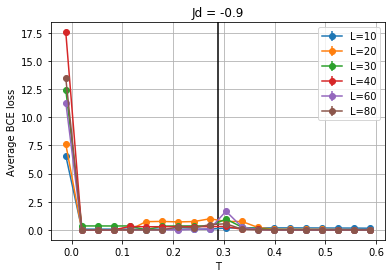

In [35]:
plt.errorbar(T, errs(errs_10), yerr=stds_err(errs_10)/1000, marker='o', label='L=10')
plt.errorbar(T, errs(errs_20), yerr=stds_err(errs_20)/1000, marker='o', label='L=20')
plt.errorbar(T, errs(errs_30), yerr=stds_err(errs_30)/1000, marker='o', label='L=30')
plt.errorbar(T, errs(errs_40), yerr=stds_err(errs_40)/1000, marker='o', label='L=40')
plt.errorbar(T, errs(errs_60), yerr=stds_err(errs_60)/1000, marker='o', label='L=60')
plt.errorbar(T, errs(errs_80), yerr=stds_err(errs_80)/1000, marker='o', label='L=80')

plt.title('Jd = -0.9')
plt.xlabel('T')
plt.ylabel('Average BCE loss')
plt.axvline(x=T_c, color='black')
plt.legend()
#plt.xlim(T_c-0.1, T_c+0.1)
plt.show()

In [36]:
Jd = -1.0

num_temps = 20
T_c = get_crit_T[Jd]
T = np.linspace(T_c - 0.3, T_c + 0.3, num_temps)

L = 10
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_10 = np.load(f) 
L = 20
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_20 = np.load(f) 
L = 30
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_30 = np.load(f)
L = 40
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_40 = np.load(f)
L = 60
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_60 = np.load(f) 
L = 80
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_80 = np.load(f) 

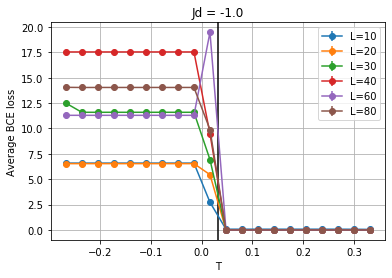

In [37]:
plt.errorbar(T, errs(errs_10), yerr=stds_err(errs_10)/1000, marker='o', label='L=10')
plt.errorbar(T, errs(errs_20), yerr=stds_err(errs_20)/1000, marker='o', label='L=20')
plt.errorbar(T, errs(errs_30), yerr=stds_err(errs_30)/1000, marker='o', label='L=30')
plt.errorbar(T, errs(errs_40), yerr=stds_err(errs_40)/1000, marker='o', label='L=40')
plt.errorbar(T, errs(errs_60), yerr=stds_err(errs_60)/1000, marker='o', label='L=60')
plt.errorbar(T, errs(errs_80), yerr=stds_err(errs_80)/1000, marker='o', label='L=80')

plt.title('Jd = -1.0')
plt.xlabel('T')
plt.ylabel('Average BCE loss')
plt.axvline(x=T_c, color='black')
plt.legend()
#plt.xlim(T_c-0.1, T_c+0.1)
plt.show()